## Load Data

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Traning Dataset

Remove about 10% of data at beginning and end of the simulation.

In [50]:
rail_df = pd.read_excel("../data/data_old/Patstitchcat_V300icat557ipat1.xlsx")
rail_df = rail_df.iloc[1000:18500]
rail_v350 = pd.read_excel("../data/data_old/Patstitchcat_V350icat557ipat1.xlsx")
rail_v350 = rail_v350.iloc[1000:16000]
rail_df = pd.concat([rail_df,rail_v350])

rail_df = rail_df.rename(index=str, columns={"Force(20Hz)": "Force","Force(raw)":"Raw_Force"})


rail_df = rail_df.dropna()
rail_df.reset_index(drop=True, inplace=True)


rail_df.head()

,Distance [m],Acceleration,Displacement,Force,Raw_Force
0,138.416667,0.785773,0.077908,186.401406,167.853064
1,138.500000,0.095516,0.077847,184.228522,173.328387
2,138.583333,-2.071776,0.077785,182.016232,189.264515
3,138.666667,-2.816802,0.077722,179.783811,195.039796
4,138.750000,-0.776615,0.077656,177.550484,180.959063


In [51]:
# import tensorflow as tf
n_time_step = 15
def create_int_feature(feature_data,n_time_step,label):
    feature_list = []
    row_num = feature_data.shape[0]
    for i in range(0, row_num, 1):
        if row_num >= i + n_time_step:
            tem_file = feature_data.iloc[i:i + n_time_step, :].values
            feature_list.append(tem_file.reshape(5,2))
    # print(len(feature_list))
    feature_df = pd.DataFrame(data={"features": feature_list,"labels":label[n_time_step-1:row_num]})
    return feature_df
    # features = np.vstack(features.values)
    # features = features.reshape(-1,5,2)
    # return feature_list,label[n_time_step-1:row_num]

In [52]:
# rail_df = rail_df.iloc[1:1000]
feature_df = create_int_feature(rail_df[['Acceleration','Displacement']],5,rail_df.Raw_Force.values)

In [53]:
features = np.vstack(feature_df.features.values)
features = features.reshape(-1,5,2)

## RNN

#### Simple RNN

In [54]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, SimpleRNN, GRU, LSTM,Input
from keras import regularizers
from keras.optimizers import RMSprop
from keras.layers import Bidirectional


In [124]:
reg = regularizers.l1_l2(0.01)
def rnn_model(steps=5,feature_size=2, output_size=1,req=True):
    model = Sequential()
    model.add(Input(shape=(steps,feature_size)))
    model.add(SimpleRNN(32,return_sequences=True,bias_regularizer=reg))
    model.add(SimpleRNN(32, return_sequences=False))
    model.add(Dense(output_size))
    model.compile(loss='mean_squared_error')
    return model

rnn = rnn_model()
rnn.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_13 (SimpleRNN)       │ (None, 5, 32)          │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_14 (SimpleRNN)       │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,233 (12.63 KB)

 Trainable params: 3,233 (12.63 KB)

 Non-trainable params: 0 (0.00 B)

In [125]:
rnn_history = rnn.fit(features, feature_df.labels, epochs=100, verbose=2)

Epoch 1/100
1016/1016 - 3s - 3ms/step - loss: 24457.3730
Epoch 2/100
1016/1016 - 2s - 2ms/step - loss: 15485.2852
Epoch 3/100
1016/1016 - 2s - 2ms/step - loss: 8876.7539
Epoch 4/100
1016/1016 - 2s - 2ms/step - loss: 4626.6826
Epoch 5/100
1016/1016 - 2s - 2ms/step - loss: 2291.2764
Epoch 6/100
1016/1016 - 2s - 2ms/step - loss: 1128.6438
Epoch 7/100
1016/1016 - 2s - 2ms/step - loss: 710.4233
Epoch 8/100
1016/1016 - 2s - 2ms/step - loss: 578.5517
Epoch 9/100
1016/1016 - 2s - 2ms/step - loss: 521.3114
Epoch 10/100
1016/1016 - 2s - 2ms/step - loss: 490.7156
Epoch 11/100
1016/1016 - 2s - 2ms/step - loss: 471.4481
Epoch 12/100
1016/1016 - 2s - 2ms/step - loss: 456.3656
Epoch 13/100
1016/1016 - 2s - 2ms/step - loss: 447.6916
Epoch 14/100
1016/1016 - 2s - 2ms/step - loss: 436.7932
Epoch 15/100
1016/1016 - 2s - 2ms/step - loss: 429.0605
Epoch 16/100
1016/1016 - 2s - 2ms/step - loss: 422.5917
Epoch 17/100
1016/1016 - 2s - 2ms/step - loss: 418.9040
Epoch 18/100
1016/1016 - 2s - 2ms/step - loss: 41

In [126]:
def lstm_model(steps=5,feature_size=2, output_size=1,req=True):
    model = Sequential()
    model.add(Input(shape=(steps,feature_size)))
    model.add(Bidirectional(LSTM(32,return_sequences=True,bias_regularizer=reg)))
    model.add(Bidirectional(LSTM(32,return_sequences=False)))
    model.add(Dense(output_size))
    model.compile(loss='mean_squared_error')
    return model

In [127]:
lstm_model = lstm_model()
lstm_model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_18                │ (None, 5, 64)          │         8,960 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_19                │ (None, 64)             │        24,832 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,857 (132.25 KB)

 Trainable params: 33,857 (132.25 KB)

 Non-trainable params: 0 (0.00 B)

In [128]:
lstm_history = lstm_model.fit(features, feature_df.labels, epochs=100, verbose=2)

Epoch 1/100
1016/1016 - 7s - 7ms/step - loss: 19339.5195
Epoch 2/100
1016/1016 - 4s - 4ms/step - loss: 6508.0098
Epoch 3/100
1016/1016 - 4s - 4ms/step - loss: 1817.3059
Epoch 4/100
1016/1016 - 4s - 4ms/step - loss: 832.3021
Epoch 5/100
1016/1016 - 4s - 4ms/step - loss: 649.0242
Epoch 6/100
1016/1016 - 4s - 4ms/step - loss: 567.0534
Epoch 7/100
1016/1016 - 4s - 4ms/step - loss: 501.1953
Epoch 8/100
1016/1016 - 4s - 4ms/step - loss: 467.3203
Epoch 9/100
1016/1016 - 5s - 5ms/step - loss: 451.5980
Epoch 10/100
1016/1016 - 4s - 4ms/step - loss: 441.1678
Epoch 11/100
1016/1016 - 4s - 4ms/step - loss: 431.5089
Epoch 12/100
1016/1016 - 4s - 4ms/step - loss: 424.9404
Epoch 13/100
1016/1016 - 4s - 4ms/step - loss: 419.0738
Epoch 14/100
1016/1016 - 4s - 4ms/step - loss: 415.9192
Epoch 15/100
1016/1016 - 4s - 4ms/step - loss: 410.9762
Epoch 16/100
1016/1016 - 4s - 4ms/step - loss: 406.4657
Epoch 17/100
1016/1016 - 4s - 4ms/step - loss: 403.4953
Epoch 18/100
1016/1016 - 4s - 4ms/step - loss: 406.10

In [129]:
rail_v380 = pd.read_excel("../data/data_old/Patstitchcat_V380icat557ipat1.xlsx") # (15111, 5)
rail_v380 = rail_v380.rename(index=str, columns={"Force(20Hz)": "Force","Force(raw)":"Raw_Force"})
rail_v380 = rail_v380.iloc[800:14100]
rail_v380 = rail_v380.dropna()
rail_v380.reset_index(drop=True, inplace=True)

In [130]:
test_df = create_int_feature(rail_v380[['Acceleration','Displacement']],5,rail_v380.Raw_Force.values)
test_features = np.vstack(test_df.features.values)
test_features = test_features.reshape(-1,5,2)

In [131]:
y_prime = test_df.labels

In [132]:
test_features.shape

(13296, 5, 2)

In [133]:
y_rnn = rnn.predict(test_features)
y_lstm = lstm_model.predict(test_features)

416/416 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [134]:
y_rnn.shape

(13296, 1)

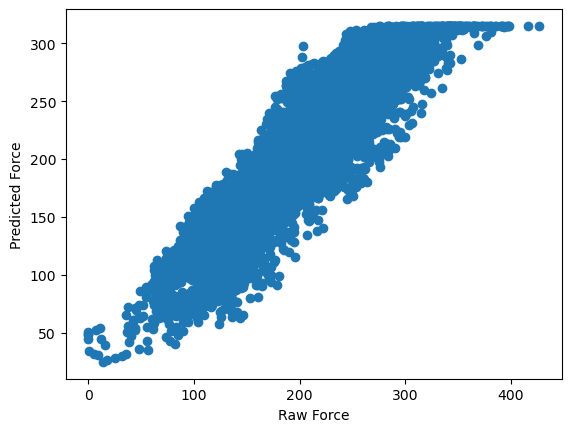

In [135]:
plt.scatter(y_prime,y_rnn);
plt.xlabel("Raw Force")
plt.ylabel("Predicted Force");

In [136]:
def plot_slot(start=500,end=601):
    epoch_count = range(start,end)

    plt.plot(epoch_count, y_prime[start:end], 'r--',linewidth=2.0)
    plt.plot(epoch_count, y_rnn[start:end], 'y--',linewidth=2.0)
    plt.plot(epoch_count, y_lstm[start:end], 'b--',linewidth=2.0)
    plt.legend(['Raw Force', "RNN pred","LSTM pred"])
    plt.xlabel('Time Slots')
    plt.ylabel('Force')
    #plt.title(title)
    plt.show()

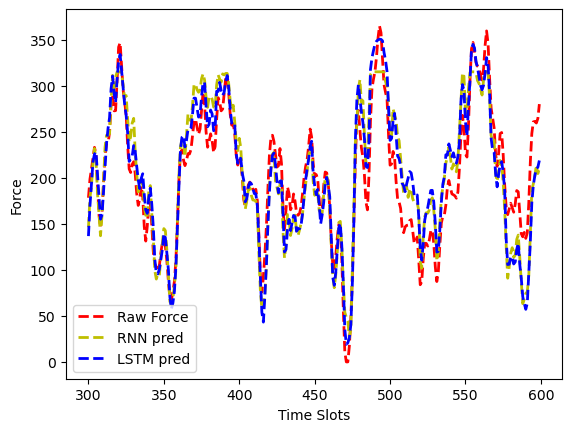

In [138]:
plot_slot(300,600)

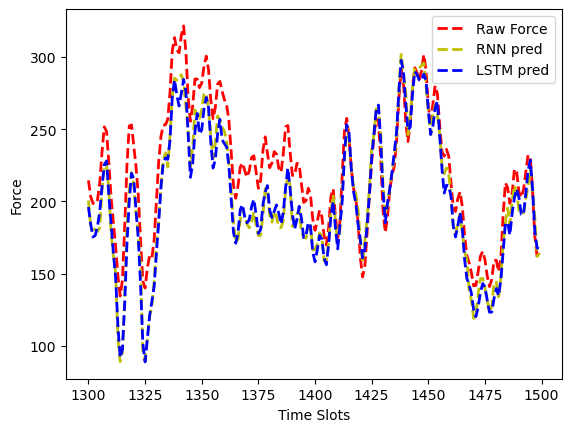

In [140]:
plot_slot(1300,1500)